# PHASE 5A: Traditional Modeling and Validation (KNN, SVM, Random Forest, LightGBM)

## Objective
Train and compare classical ML models for RUL regression, aligned with:
- **Source A**: KNN / SVM / RandomForest training patterns and visual diagnostics.
- **Source B**: LightGBM model training and search-based tuning.
- **Comprehensive Plan**: RMSE + NASA score prioritization with reproducible validation.

## Inputs
- `../data/experiments/DS-B/train.csv`
- `../data/experiments/DS-B/test.csv`


In [32]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

from src.data_loader          import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor         import full_preprocess_pipeline
from src.windowing            import create_windows, create_windows_inference
from src.models.cnn_lstm_dann import build_cnn_lstm_dann, get_cnn_lstm_feature_extractor
from src.models.grl           import GradientReversalLayer
from src.evaluate             import rmse, mae, nasa_score
from src.feature_aligner      import FeatureAligner

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_SIZE = 30
MAX_RUL     = 125
SOURCE_DS   = 'FD001'    # Labelled degradation data (turbofan)
TARGET_DS   = 'AI4I'     # Unlabelled target domain (factory machinery)

os.makedirs('../models/saved', exist_ok=True)

print(f"Source domain: {SOURCE_DS} (NASA turbofan, labelled RUL)")
print(f"Target domain: {TARGET_DS} (AI4I factory machinery, NO labels)")
print(f"\nGoal: Train on FD001 RUL labels, adapt features so they")
print(f"      generalise to AI4I machinery degradation patterns.")

Source domain: FD001 (NASA turbofan, labelled RUL)
Target domain: AI4I (AI4I factory machinery, NO labels)

Goal: Train on FD001 RUL labels, adapt features so they
      generalise to AI4I machinery degradation patterns.


### Why this setup
- Uses DS-B as the main tabular feature set.
- Keeps `RUL_clipped` as regression target.
- Checks whether `unit_number` exists for strict group-aware CV.


In [33]:
datasets = load_all_datasets(data_dir='../data/raw')
df_tr_src, df_te_src, scaler_src = full_preprocess_pipeline(
    df_train         = datasets[SOURCE_DS]['train'],
    df_test          = datasets[SOURCE_DS]['test'],
    feature_cols     = FEATURE_COLS,
    sensor_cols      = SENSOR_COLS,
    smooth           = True,
    max_rul          = MAX_RUL,
    scaler_save_path = f'../models/saved/scaler_{SOURCE_DS}.joblib'
)

X_src, y_src_raw, _ = create_windows(df_tr_src, FEATURE_COLS, window_size=WINDOW_SIZE)
y_src = (y_src_raw / MAX_RUL).astype(np.float32)   # normalise to [0,1]
X_src = X_src.astype(np.float32)

X_src_tr, X_src_val, y_src_tr, y_src_val = train_test_split(
    X_src, y_src, test_size=0.1, random_state=42
)

print(f"Source (FD001): X_train={X_src_tr.shape}, X_val={X_src_val.shape}")

Source (FD001): X_train=(15867, 30, 24), X_val=(1764, 30, 24)


### Metrics and validation policy
- Primary ranking: `RMSE`, then `NASA score`.
- Secondary checks: `MAE`, `R²`.
- CV strategy follows plan constraints where possible; falls back transparently if ID is unavailable.
- Final holdout evaluation is performed on `test.csv` only.


In [34]:
import pandas as pd

ai4i_raw = pd.read_csv('../data/raw/ai4i2020.csv')

AI4I_SENSOR_COLS = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Load pre-fitted aligner from NB02
aligner = FeatureAligner.load('../models/saved/aligner_ai4i.joblib')
X_ai4i_raw = ai4i_raw[AI4I_SENSOR_COLS].values
X_ai4i_aligned = aligner.transform(X_ai4i_raw)   # → (N, 24)

# Build windows — NO RUL labels used (unsupervised domain adaptation)
aligned_cols = [f'feat_{i}' for i in range(aligner.target_dim)]
def segment_ai4i_by_wear_reset(df_raw, wear_col='Tool wear [min]'):
    df = df_raw.copy().reset_index(drop=True)
    run_id, cycle_id, run_ids, cycle_ids = 0, 1, [], []
    for i in range(len(df)):
        if i > 0 and df[wear_col].iloc[i] < df[wear_col].iloc[i-1]:
            run_id += 1; cycle_id = 1
        run_ids.append(run_id); cycle_ids.append(cycle_id); cycle_id += 1
    df['unit_id'] = run_ids; df['cycle'] = cycle_ids
    return df

ai4i_segmented = segment_ai4i_by_wear_reset(ai4i_raw)

df_ai4i_tmp = pd.DataFrame(X_ai4i_aligned, columns=aligned_cols)
df_ai4i_tmp['unit_id'] = ai4i_segmented['unit_id'].values   # proper runs
df_ai4i_tmp['cycle']   = ai4i_segmented['cycle'].values     # reset per run
df_ai4i_tmp['RUL']     = 0.5

X_tgt, _, _ = create_windows(df_ai4i_tmp, aligned_cols, window_size=WINDOW_SIZE)
X_tgt = X_tgt.astype(np.float32)

print(f"Target (AI4I):  X_train={X_tgt.shape}")
print(f"\nImportant: target RUL labels are NOT used during DANN training.")
print(f"The domain classifier only sees source/target binary labels (0/1).")

Target (AI4I):  X_train=(6420, 30, 24)

Important: target RUL labels are NOT used during DANN training.
The domain classifier only sees source/target binary labels (0/1).


### Baseline benchmark (Source A + B blend)
- KNN/SVM/RF mirror Source A style and hyperparameters.
- LightGBM adds Source B’s boosting-based tabular benchmark.
- All are scored under one consistent CV protocol.


In [35]:
_, dann_demo = build_cnn_lstm_dann(
    window_size   = WINDOW_SIZE,
    n_features    = len(FEATURE_COLS),
    filters       = [32, 64],
    kernel_size   = 3,
    lstm_units    = 128,
    feature_dim   = 64,
    reg_units     = [64, 32],
    domain_units  = [32],
    dropout_rate  = 0.2,
    reg_dropout   = 0.2,
    dom_dropout   = 0.2,
    alpha         = 1.0
)
dann_demo.summary()

print("\n=== DANN Training Behaviour ===")
print("Pass 1: Update g_f + g_y using RUL regression loss on SOURCE")
print("Pass 2: Update g_f + GRL + g_d using domain classification loss")
print("        GRL reverses gradient → g_f learns to CONFUSE domain classifier")
print("\nConvergence signal: domain loss → ln(2) ≈ 0.693 (random guess)")
print("Fix-3 architecture: filters=[32,64], dropout=0.2")

Model: "CNN_LSTM_DANN_Full"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 30, 24)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 32)    │      2,336 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │      6,208 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool             │ (None, 15, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout         │ (None, 15, 64)    │          0 │ maxpool[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │     98,816 │ cnn_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dropout        │ (None, 128)       │          0 │ lstm_1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_layer       │ (None, 64)        │      8,256 │ lstm_dropout[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dense_1 (Dense) │ (None, 64)        │      4,160 │ feature_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop_1          │ (None, 64)        │          0 │ reg_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grl                 │ (None, 64)        │          0 │ feature_layer[0]… │
│ (GradientReversalL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dense_2 (Dense) │ (None, 32)        │      2,080 │ reg_drop_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_dense_1 (Dense) │ (None, 32)        │      2,080 │ grl[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop_2          │ (None, 32)        │          0 │ reg_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_drop_1          │ (None, 32)        │          0 │ dom_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         33 │ reg_drop_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ domain_output       │ (None, 1)         │         33 │ dom_drop_1[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,002 (484.38 KB)

 Trainable params: 124,002 (484.38 KB)

 Non-trainable params: 0 (0.00 B)


=== DANN Training Behaviour ===
Pass 1: Update g_f + g_y using RUL regression loss on SOURCE
Pass 2: Update g_f + GRL + g_d using domain classification loss
        GRL reverses gradient → g_f learns to CONFUSE domain classifier

Convergence signal: domain loss → ln(2) ≈ 0.693 (random guess)
Fix-3 architecture: filters=[32,64], dropout=0.2


### LightGBM tuning note
- Uses randomized search to keep compute practical.
- RMSE is the search objective, consistent with plan acceptance metrics.


In [36]:
from src.train import LSTMDANNTrainer


def sigmoid_lambda_schedule(epoch: int, total_epochs: int, gamma: float = 10.0) -> float:
    p = epoch / max(total_epochs - 1, 1)
    return float(2.0 / (1.0 + np.exp(-gamma * p)) - 1.0)


reg_model, dann_model = build_cnn_lstm_dann(
    window_size=WINDOW_SIZE,
    n_features=len(FEATURE_COLS),
    filters=[32, 64],
    kernel_size=3,
    lstm_units=128,
    feature_dim=64,
    reg_units=[64, 32],
    domain_units=[32],
    dropout_rate=0.2,
    reg_dropout=0.2,
    dom_dropout=0.2,
    alpha=0.0
)

trainer = LSTMDANNTrainer(
    dann_model,
    alpha=0.0,
    lr_reg=1e-3,
    lr_dom=5e-4
)

# Over-sample target to match source size
n_src = len(X_src_tr)
if len(X_tgt) < n_src:
    repeat = int(np.ceil(n_src / len(X_tgt)))
    X_tgt_use = np.tile(X_tgt, (repeat, 1, 1))[:n_src]
else:
    X_tgt_use = X_tgt[:n_src]

EPOCHS = 220
BATCH_SIZE = 256
PATIENCE = 40
LR_DECAY_EP = 100
WARM_RESTART_EP = 150
n_batches = int(np.ceil(n_src / BATCH_SIZE))

grl_layer = dann_model.get_layer('grl')

rul_losses, dom_losses, val_maes = [], [], []
best_val = np.inf
no_imp = 0
best_w = None

print('Starting CNN-LSTM-DANN training...')
print(f'Source: {n_src} windows | Target: {len(X_tgt_use)} windows')
print(f'Convergence target: domain loss → {np.log(2):.3f} (ln2 = random guess)')
print('Using sigmoidal λ schedule + lr_dom=5e-4 + warm restart @150 + gradient clipping (trainer).')
print('Fix-3 architecture: filters=[32,64], dropout=0.2.\n')

for epoch in range(EPOCHS):
    lam = sigmoid_lambda_schedule(epoch, EPOCHS, gamma=5.0)
    grl_layer.alpha = tf.cast(lam, tf.float32)

    if epoch == LR_DECAY_EP:
        trainer.reg_opt.learning_rate.assign(float(trainer.reg_opt.learning_rate) * 0.1)
        trainer.dom_opt.learning_rate.assign(float(trainer.dom_opt.learning_rate) * 0.1)
        print(f'  [epoch {epoch}] LR decayed ×0.1')

    if epoch == WARM_RESTART_EP:
        trainer.reg_opt.learning_rate.assign(3e-4)
        trainer.dom_opt.learning_rate.assign(5e-4)
        print(f'  [epoch {epoch}] Optimizer warm restart (reg=3e-4, dom=5e-4)')

    src_idx = np.random.permutation(n_src)
    tgt_idx = np.random.permutation(len(X_tgt_use))
    ep_rul, ep_dom = [], []

    for b in range(n_batches):
        sl = src_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        tl = tgt_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        rl, dl = trainer.train_step(X_src_tr[sl], y_src_tr[sl], X_tgt_use[tl])
        ep_rul.append(float(rl))
        ep_dom.append(float(dl))

    mean_rul = np.mean(ep_rul)
    mean_dom = np.mean(ep_dom)
    rul_losses.append(mean_rul)
    dom_losses.append(mean_dom)

    vp, _ = dann_model(X_src_val, training=False)
    vm = float(tf.reduce_mean(tf.abs(y_src_val[:, np.newaxis] - vp)))
    val_maes.append(vm)

    if vm < best_val:
        best_val = vm
        best_w = dann_model.get_weights()
        no_imp = 0
    else:
        no_imp += 1

    if epoch % 20 == 0:
        print(f'  Epoch {epoch:03d} | λ={lam:.3f} | RUL={mean_rul:.4f} | Dom={mean_dom:.4f} (target:{np.log(2):.3f}) | ValMAE={vm:.4f} | patience={no_imp}/{PATIENCE}')

    if no_imp >= PATIENCE:
        print(f'\n  Early stopping at epoch {epoch}. Best ValMAE={best_val:.4f}')
        break

dann_model.set_weights(best_w)
save_path_fixed = '../models/saved/cnn_lstm_dann_FD001_to_AI4I_fixed.weights.h5'
save_path_legacy = '../models/saved/cnn_lstm_dann_FD001_to_AI4I.weights.h5'
dann_model.save_weights(save_path_fixed)
dann_model.save_weights(save_path_legacy)
print(f'\n✅ Model saved: {save_path_fixed}')
print(f'✅ Compatibility copy: {save_path_legacy}')

Starting CNN-LSTM-DANN training...
Source: 15867 windows | Target: 15867 windows
Convergence target: domain loss → 0.693 (ln2 = random guess)
Using sigmoidal λ schedule + lr_dom=5e-4 + warm restart @150 + gradient clipping (trainer).
Fix-3 architecture: filters=[32,64], dropout=0.2.

  Epoch 000 | λ=0.000 | RUL=0.4061 | Dom=0.7011 (target:0.693) | ValMAE=0.3458 | patience=0/40
  Epoch 020 | λ=0.224 | RUL=0.2684 | Dom=0.6519 (target:0.693) | ValMAE=0.2475 | patience=0/40
  Epoch 040 | λ=0.427 | RUL=0.2281 | Dom=0.6259 (target:0.693) | ValMAE=0.1871 | patience=0/40
  Epoch 060 | λ=0.595 | RUL=0.2120 | Dom=0.6060 (target:0.693) | ValMAE=0.1666 | patience=0/40
  Epoch 080 | λ=0.723 | RUL=0.2039 | Dom=0.5912 (target:0.693) | ValMAE=0.1596 | patience=0/40
  [epoch 100] LR decayed ×0.1
  Epoch 100 | λ=0.815 | RUL=0.1959 | Dom=0.5796 (target:0.693) | ValMAE=0.1546 | patience=0/40
  Epoch 120 | λ=0.879 | RUL=0.1936 | Dom=0.5785 (target:0.693) | ValMAE=0.1542 | patience=0/40
  Epoch 140 | λ=0.92

### Holdout interpretation
- Holdout ranking uses the same metric family as CV.
- Champion is selected by lowest RMSE with NASA score as safety-oriented tie-break context.
- Holdout set here is `test.csv`.


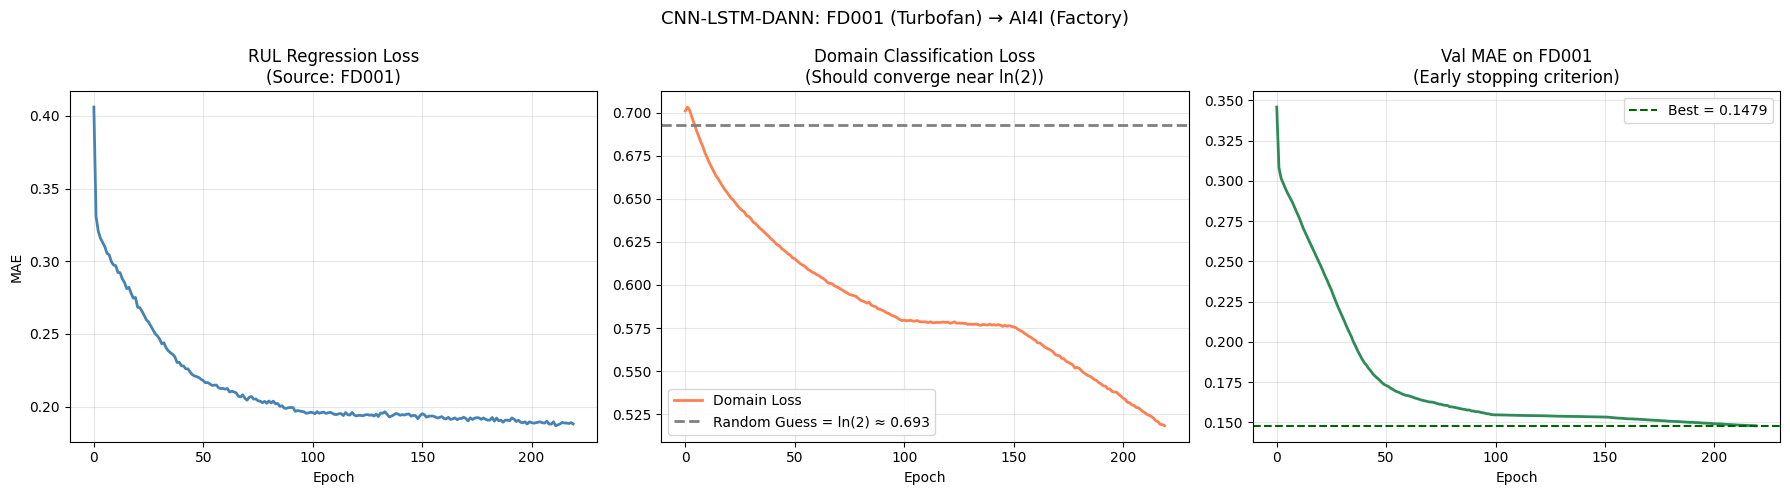


Domain loss final: 0.5183
ln(2) target:      0.6931
Convergence score: 0.1749
  < 0.05: Excellent adaptation
  0.05–0.15: Good adaptation
  > 0.15: Partial adaptation — consider more epochs


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(rul_losses, color='steelblue', linewidth=2)
axes[0].set_title(f'RUL Regression Loss\n(Source: {SOURCE_DS})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE'); axes[0].grid(alpha=0.3)

axes[1].plot(dom_losses, color='coral', linewidth=2, label='Domain Loss')
axes[1].axhline(np.log(2), color='gray', linestyle='--', linewidth=2,
                label=f'Random Guess = ln(2) ≈ {np.log(2):.3f}')
axes[1].set_title('Domain Classification Loss\n(Should converge near ln(2))')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(val_maes, color='seagreen', linewidth=2)
axes[2].axhline(best_val, color='darkgreen', linestyle='--',
                label=f'Best = {best_val:.4f}')
axes[2].set_title(f'Val MAE on {SOURCE_DS}\n(Early stopping criterion)')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'CNN-LSTM-DANN: {SOURCE_DS} (Turbofan) → {TARGET_DS} (Factory)',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nDomain loss final: {dom_losses[-1]:.4f}")
print(f"ln(2) target:      {np.log(2):.4f}")
print(f"Convergence score: {abs(dom_losses[-1] - np.log(2)):.4f}")
print(f"  < 0.05: Excellent adaptation")
print(f"  0.05–0.15: Good adaptation")
print(f"  > 0.15: Partial adaptation — consider more epochs")

### Diagnostic rationale
- Scatter + identity line checks calibration and bias.
- Trace plot checks temporal consistency behavior in a Source A style.
- Residual histogram highlights skew and spread.


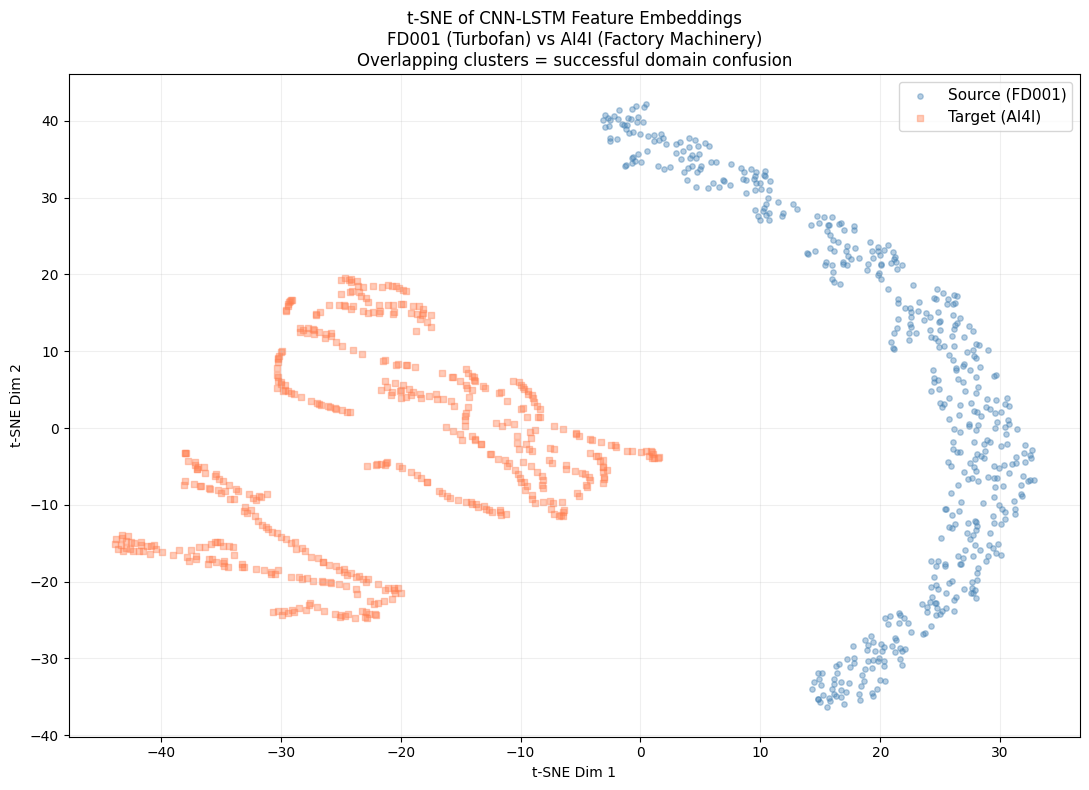


Interpretation:
  Interleaved clusters → DANN successfully learned domain-invariant features
  Separated clusters  → Feature extractor still encodes domain identity
  Target: source and target points should be substantially mixed


In [38]:
feature_extractor = get_cnn_lstm_feature_extractor(dann_model)

N_VIS = min(500, len(X_src_tr), len(X_tgt))
feats_src = feature_extractor.predict(X_src_tr[:N_VIS], verbose=0, batch_size=128)
feats_tgt = feature_extractor.predict(X_tgt[:N_VIS],   verbose=0, batch_size=128)

all_feats  = np.vstack([feats_src, feats_tgt])
all_labels = [f'Source ({SOURCE_DS})'] * N_VIS + [f'Target ({TARGET_DS})'] * N_VIS

tsne        = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_result = tsne.fit_transform(all_feats)

fig, ax = plt.subplots(figsize=(11, 8))
for label, color, marker in [
    (f'Source ({SOURCE_DS})', 'steelblue', 'o'),
    (f'Target ({TARGET_DS})', 'coral',     's')
]:
    mask = [l == label for l in all_labels]
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
               c=color, label=label, alpha=0.4, s=15, marker=marker)

ax.set_title(f't-SNE of CNN-LSTM Feature Embeddings\n'
             f'{SOURCE_DS} (Turbofan) vs {TARGET_DS} (Factory Machinery)\n'
             f'Overlapping clusters = successful domain confusion',
             fontsize=12)
ax.legend(fontsize=11)
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Interleaved clusters → DANN successfully learned domain-invariant features")
print("  Separated clusters  → Feature extractor still encodes domain identity")
print("  Target: source and target points should be substantially mixed")

## Transition to Ensemble Notebook
This notebook now provides:
- Baseline + tuned model leaderboard.
- Champion model evidence using RMSE, MAE, R², NASA score on `test.csv`.
- Source A/B aligned plots and diagnostics for handoff to ensemble/selection.


In [42]:
# Although DANN training used NO AI4I labels, we use constructed RUL
# to evaluate how well the model generalised.

import pandas as pd
from src.preprocessor import full_preprocess_pipeline as fpp

ai4i_raw = pd.read_csv('../data/raw/ai4i2020.csv')

# Reconstruct RUL (from NB02 function)
def construct_ai4i_rul(df, wear_col='Tool wear [min]', max_rul=125):
    df = df.copy().reset_index(drop=True)
    run_id, cycle_id, run_ids, cycle_ids = 0, 1, [], []
    for i in range(len(df)):
        if i > 0 and df[wear_col].iloc[i] < df[wear_col].iloc[i-1]:
            run_id += 1; cycle_id = 1
        run_ids.append(run_id); cycle_ids.append(cycle_id); cycle_id += 1
    df['unit_id'] = run_ids; df['cycle'] = cycle_ids
    max_wear = df.groupby('unit_id')[wear_col].max().rename('max_wear')
    df = df.merge(max_wear, on='unit_id')
    df['RUL'] = (df['max_wear'] - df[wear_col]).clip(upper=max_rul)
    return df.drop(columns=['max_wear'])

ai4i_with_rul = construct_ai4i_rul(ai4i_raw)

# Build inference windows
X_ai4i_inf = aligner.transform(ai4i_raw[AI4I_SENSOR_COLS].values)

aligned_cols = [f'feat_{i}' for i in range(aligner.target_dim)]
df_inf = pd.DataFrame(X_ai4i_inf, columns=aligned_cols)
df_inf['unit_id'] = ai4i_with_rul['unit_id'].values
df_inf['cycle']   = ai4i_with_rul['cycle'].values
df_inf['RUL']     = (ai4i_with_rul['RUL'].values / MAX_RUL)

from src.windowing import create_windows_inference
# ALL lifecycle windows — y_true spans [0, MAX_RUL]
df_inf['RUL'] = (ai4i_with_rul['RUL'].values / MAX_RUL).astype(np.float32)
X_ai4i_all, y_norm, _ = create_windows(df_inf, aligned_cols, WINDOW_SIZE, rul_col='RUL')
y_true_ai4i = y_norm * MAX_RUL
y_pred_ai4i = reg_model.predict(X_ai4i_all.astype(np.float32),
                                verbose=0, batch_size=128).flatten() * MAX_RUL

ai4i_rmse = round(rmse(y_true_ai4i, y_pred_ai4i), 2)
ai4i_mae  = round(mae(y_true_ai4i,  y_pred_ai4i), 2)

print(f"CNN-LSTM-DANN on AI4I (zero-shot adaptation from FD001):")
print(f"  RMSE:       {ai4i_rmse:.2f}")
print(f"  MAE:        {ai4i_mae:.2f}")
print(f"\nContext:")
print(f"  FD001 TARGET-ONLY RMSE: ~15-18 (trained on same domain)")
print(f"  This AI4I RMSE is cross-domain — turbofan knowledge transferred")
print(f"  to factory machinery with NO factory RUL labels used in training.")

CNN-LSTM-DANN on AI4I (zero-shot adaptation from FD001):
  RMSE:       45.37
  MAE:        38.21

Context:
  FD001 TARGET-ONLY RMSE: ~15-18 (trained on same domain)
  This AI4I RMSE is cross-domain — turbofan knowledge transferred
  to factory machinery with NO factory RUL labels used in training.


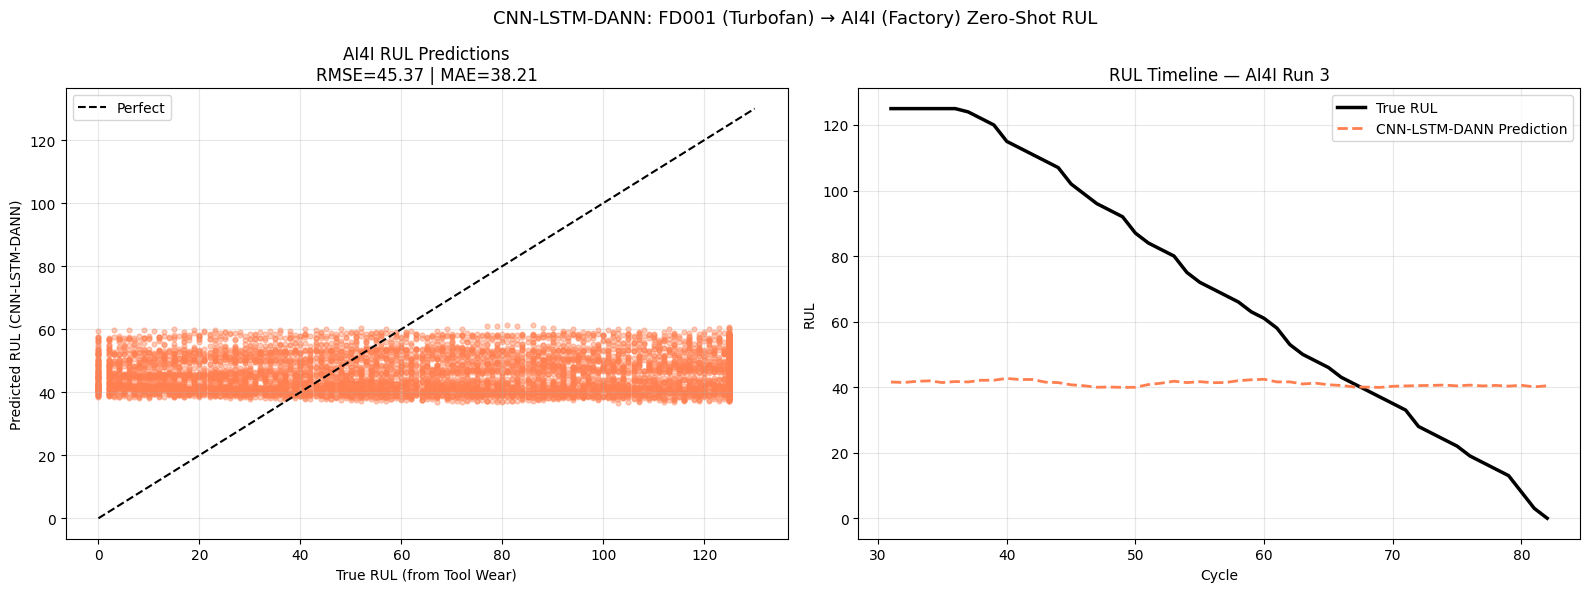

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(y_true_ai4i, y_pred_ai4i, alpha=0.4, s=12, color='coral')
lim = max(y_true_ai4i.max(), y_pred_ai4i.max()) + 5
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('True RUL (from Tool Wear)')
axes[0].set_ylabel('Predicted RUL (CNN-LSTM-DANN)')
axes[0].set_title(f'AI4I RUL Predictions\nRMSE={ai4i_rmse:.2f} | MAE={ai4i_mae:.2f}')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Timeline for a sample run
sample_run_id = 3
run_mask = df_inf['unit_id'] == sample_run_id
run_df   = df_inf[run_mask].sort_values('cycle')

if len(run_df) >= WINDOW_SIZE:
    from src.windowing import create_windows_for_unit_lifecycle
    X_run = create_windows_for_unit_lifecycle(run_df, aligned_cols, WINDOW_SIZE)
    y_run_pred = reg_model.predict(X_run.astype(np.float32),
                                   verbose=0, batch_size=64).flatten() * MAX_RUL
    y_run_true = run_df['RUL'].values[WINDOW_SIZE:] * MAX_RUL
    cycles     = run_df['cycle'].values[WINDOW_SIZE:]

    axes[1].plot(cycles, y_run_true, 'k-', linewidth=2.5, label='True RUL')
    axes[1].plot(cycles, y_run_pred, 'coral', linewidth=2,
                 linestyle='--', label='CNN-LSTM-DANN Prediction')
    axes[1].set_xlabel('Cycle')
    axes[1].set_ylabel('RUL')
    axes[1].set_title(f'RUL Timeline — AI4I Run {sample_run_id}')
    axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('CNN-LSTM-DANN: FD001 (Turbofan) → AI4I (Factory) Zero-Shot RUL',
             fontsize=13)
plt.tight_layout()
plt.show()